# Evaluation Results Comparison

In [45]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "#FAFAFA",
    "axes.titlesize": 13,
    "axes.titleweight": "bold",
    "axes.labelsize": 10,
    "axes.edgecolor": "#DDDDDD",
    "grid.color": "#D8D8D8",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.55,
    "legend.frameon": False,
    "legend.fontsize": 9,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

## Content Based Models

In [57]:
CB_EVALUATION_RESULTS_CSV = "../reports/evaluation_results.csv"

df = pd.read_csv(CB_EVALUATION_RESULTS_CSV)
df.head(20)

,model,n_users,hr@5,p@5,r@5,ndcg@5,hr@10,p@10,r@10,ndcg@10,hr@20,p@20,r@20,ndcg@20
0,cb1_weighted,62411,0.009213,0.002083,0.000807,0.002097,0.016952,0.002109,0.001631,0.002267,0.028713,0.002078,0.003204,0.002800
1,cb1_mean_centering,62411,0.108747,0.026108,0.011058,0.028176,0.167679,0.022453,0.018691,0.026947,0.244396,0.018671,0.030795,0.029528
2,cb2_weighted,62411,0.016279,0.003333,0.001492,0.003350,0.033776,0.003547,0.003081,0.003829,0.066367,0.003671,0.006284,0.005052
3,cb2_mean_centering,62411,0.021230,0.004400,0.001772,0.004540,0.040522,0.004419,0.003522,0.004848,0.072551,0.004195,0.006628,0.005825
4,cb3_weighted,62411,0.012049,0.002733,0.001215,0.002662,0.025092,0.003088,0.002712,0.003200,0.053612,0.003531,0.006437,0.004731
5,cb3_mean_centering,62411,0.097034,0.022743,0.009438,0.024788,0.147859,0.019173,0.015794,0.023314,0.217510,0.015883,0.025695,0.025235
6,cb4_weighted,62411,0.004663,0.000977,0.000464,0.001004,0.012370,0.001375,0.001386,0.001410,0.038182,0.002259,0.004719,0.002947
7,cb4_mean_centering,62411,0.138453,0.033859,0.014167,0.036515,0.209290,0.028934,0.023990,0.034755,0.298361,0.024068,0.039184,0.037864
8,cb5_weighted,62411,0.017112,0.003512,0.001381,0.003729,0.032863,0.003414,0.002702,0.003872,0.059925,0.003265,0.005106,0.004626
9,cb5_mean_centering,62411,0.019307,0.003993,0.001501,0.004083,0.035362,0.003741,0.002735,0.004128,0.065229,0.003570,0.005370,0.004920


In [47]:
# Prepare data for plotting
plot_df = df.copy()
plot_df[["base_model", "variant"]] = plot_df["model"].str.extract(r"^(cb\d+)_(.*)$")
plot_df["model_num"] = plot_df["base_model"].str.extract(r"(\d+)").astype(int)
plot_df = plot_df.sort_values(["model_num", "variant"])

base_order = plot_df["base_model"].drop_duplicates().tolist()
variant_order = [v for v in ["weighted", "mean_centering"] if v in plot_df["variant"].unique()]
variant_palette = sns.color_palette("Set2", n_colors=max(2, len(variant_order)))
colors = dict(zip(variant_order, variant_palette))

def style_axis(ax, ylabel=None):
    ax.grid(axis="y", linestyle="--", linewidth=0.9, alpha=0.6)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)
    sns.despine(ax=ax, top=True, right=True)
    if ylabel is not None:
        ax.set_ylabel(ylabel)

def add_bar_labels(ax, fmt=None):
    for container in ax.containers:
        labels = []
        for value in container.datavalues:
            if value != value:
                labels.append("")
            elif fmt is not None:
                labels.append(fmt.format(value))
            elif abs(value) < 0.1:
                labels.append(f"{value:.4f}")
            else:
                labels.append(f"{value:.3f}")
        ax.bar_label(container, labels=labels, padding=2, fontsize=8)
    ymin, ymax = ax.get_ylim()
    if ymax > 0:
        ax.set_ylim(ymin, ymax * 1.08)

def plot_grouped_metric(metric, title, ax):
    pivot = (
        plot_df
        .pivot(index="base_model", columns="variant", values=metric)
        .reindex(base_order)
    )

    pivot[variant_order].plot(
        kind="bar",
        ax=ax,
        color=[colors[v] for v in variant_order],
        width=0.78,
        edgecolor="white",
        linewidth=0.8
    )
    ax.set_title(title, pad=10)
    ax.set_xlabel("Base model")
    ax.tick_params(axis="x", rotation=0)
    style_axis(ax, metric)
    add_bar_labels(ax)

### Comparison at K = 10

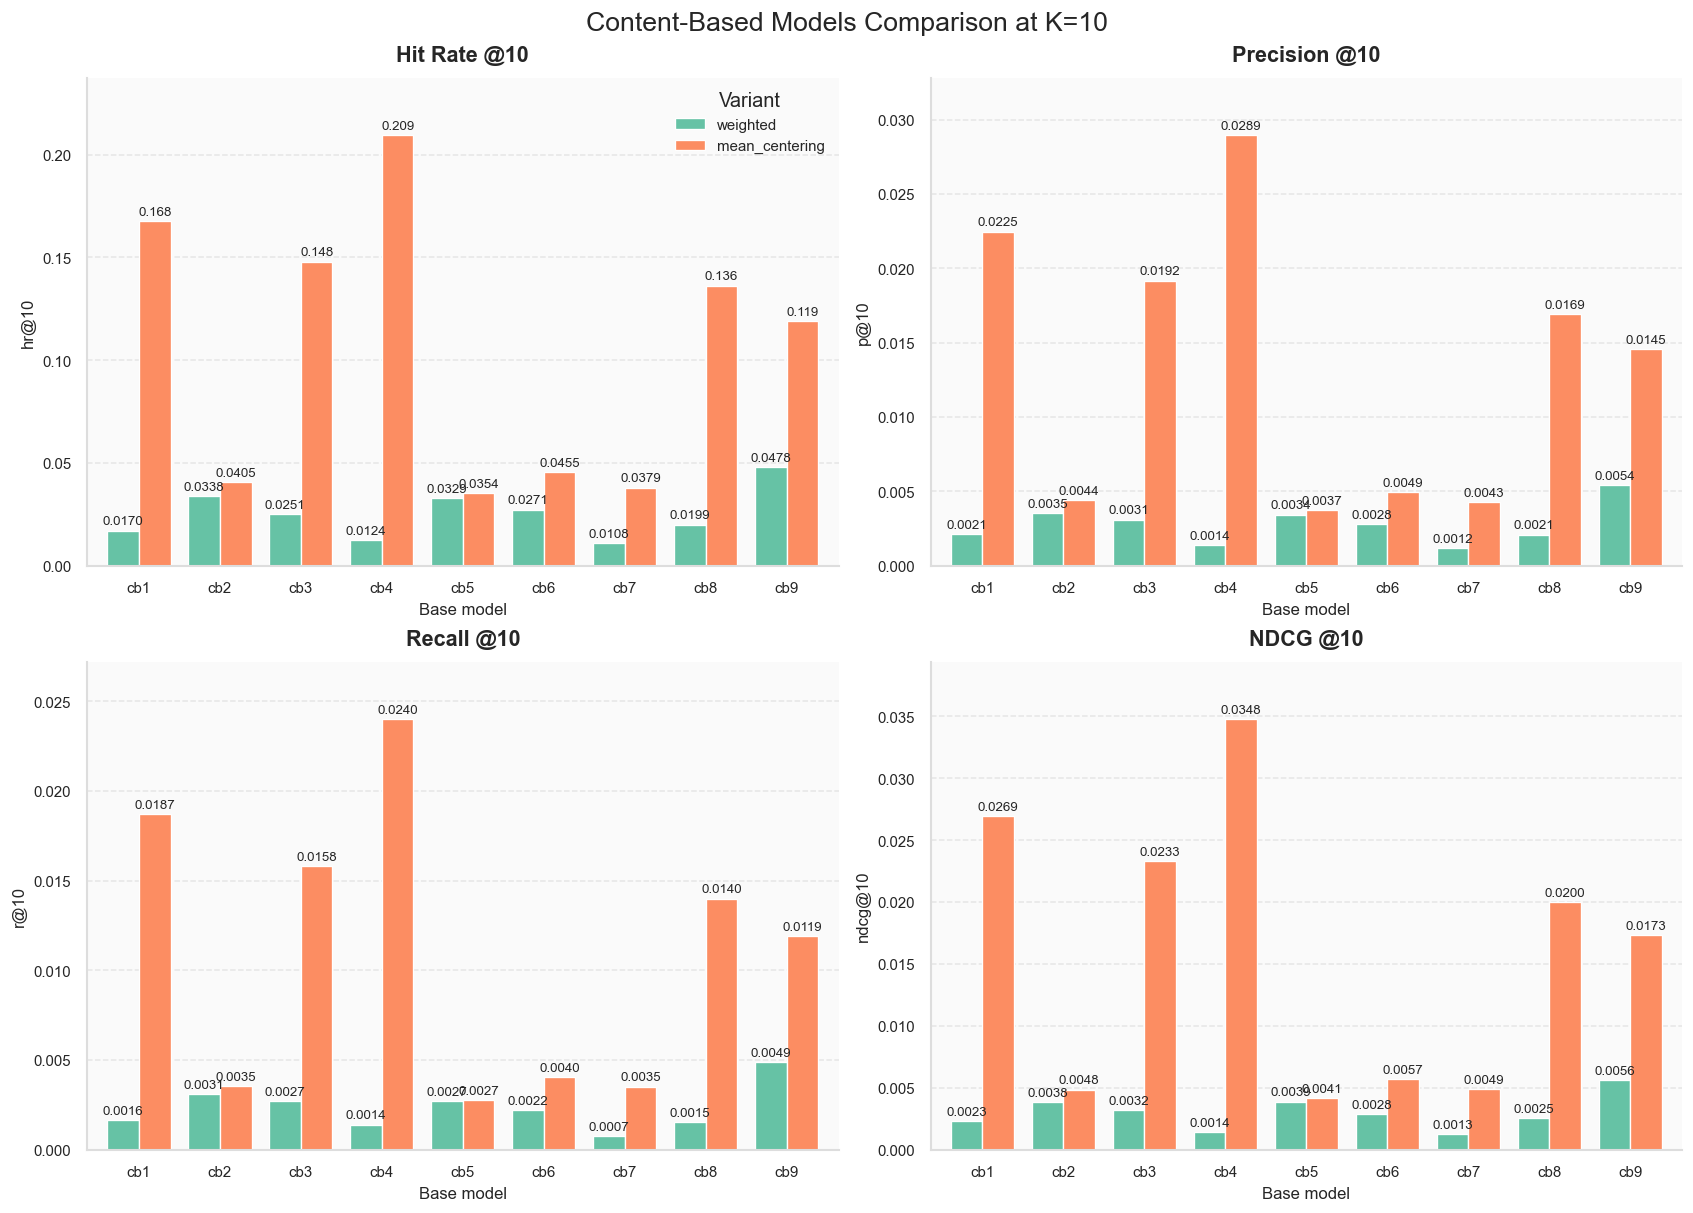

In [48]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)

plot_grouped_metric("hr@10", "Hit Rate @10", axes[0, 0])
plot_grouped_metric("p@10", "Precision @10", axes[0, 1])
plot_grouped_metric("r@10", "Recall @10", axes[1, 0])
plot_grouped_metric("ndcg@10", "NDCG @10", axes[1, 1])

for ax in axes.flat[1:]:
    ax.get_legend().remove()

axes[0, 0].legend(title="Variant")
fig.suptitle("Content-Based Models Comparison at K=10", fontsize=16)
plt.show()

### Top models across K = 5, 10, 20

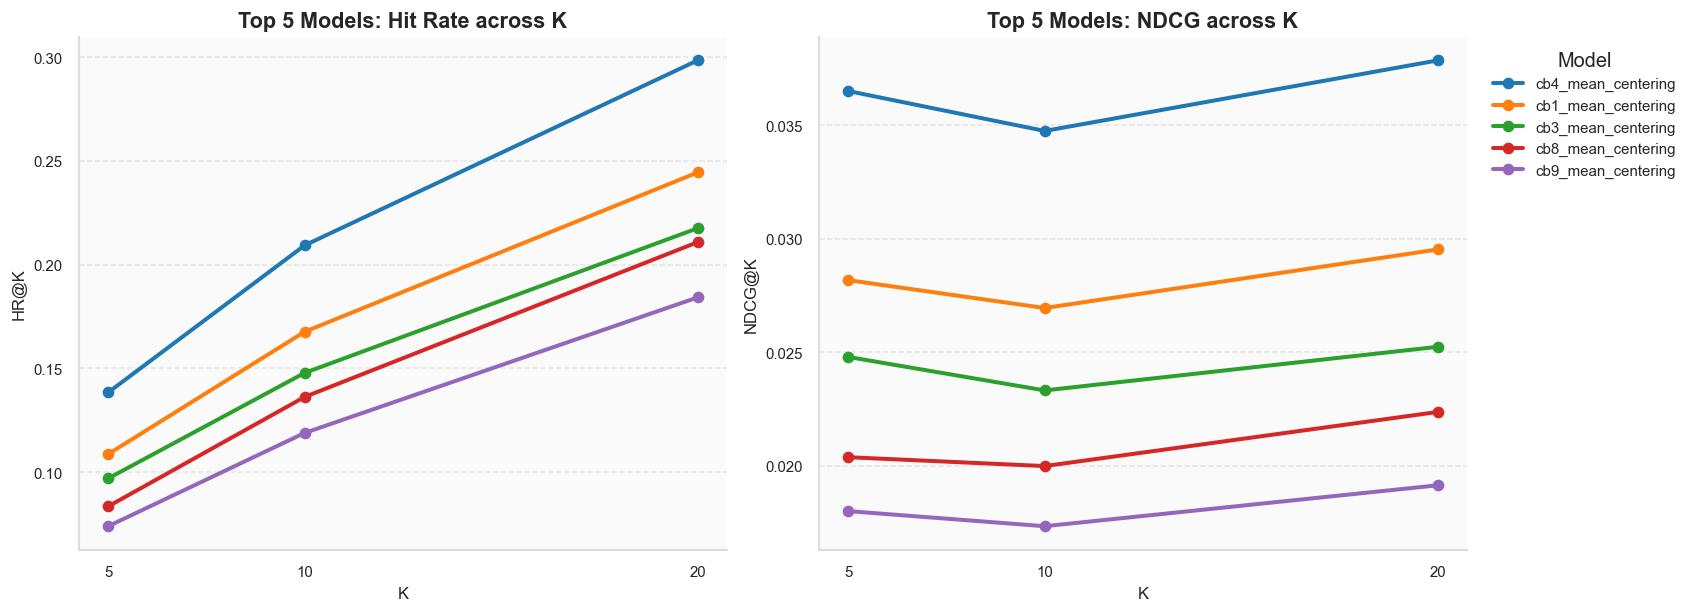

In [49]:
k_values = [5, 10, 20]
top_models = plot_df.nlargest(5, "ndcg@10")["model"].tolist()
line_palette = sns.color_palette("tab10", n_colors=len(top_models))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for idx, model_name in enumerate(top_models):
    row = plot_df.loc[plot_df["model"] == model_name].iloc[0]

    axes[0].plot(
        k_values,
        [row[f"hr@{k}"] for k in k_values],
        marker="o",
        linewidth=2.4,
        markersize=6,
        color=line_palette[idx],
        label=model_name
    )
    axes[1].plot(
        k_values,
        [row[f"ndcg@{k}"] for k in k_values],
        marker="o",
        linewidth=2.4,
        markersize=6,
        color=line_palette[idx],
        label=model_name
    )

axes[0].set_title("Top 5 Models: Hit Rate across K")
axes[0].set_xlabel("K")
axes[0].set_ylabel("HR@K")
axes[0].set_xticks(k_values)
style_axis(axes[0])

axes[1].set_title("Top 5 Models: NDCG across K")
axes[1].set_xlabel("K")
axes[1].set_ylabel("NDCG@K")
axes[1].set_xticks(k_values)
style_axis(axes[1])
axes[1].legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.show()

### Average performance by variant - mean-centering vs weighted 

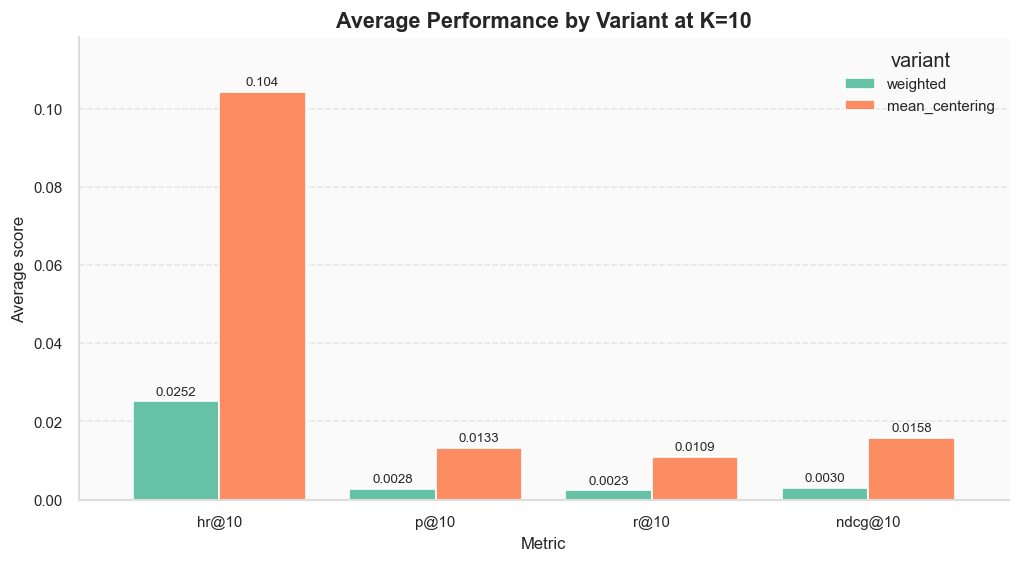

Best model by NDCG@10: cb4_mean_centering


In [50]:
variant_summary = (
    plot_df
    .groupby("variant")[["hr@10", "p@10", "r@10", "ndcg@10"]]
    .mean()
    .T
)

ax = variant_summary[variant_order].plot(
    kind="bar",
    figsize=(10, 5),
    color=[colors[v] for v in variant_order],
    width=0.8
)
ax.set_title("Average Performance by Variant at K=10")
ax.set_xlabel("Metric")
ax.tick_params(axis="x", rotation=0)
style_axis(ax, "Average score")
add_bar_labels(ax)
plt.show()

best_model = plot_df.sort_values("ndcg@10", ascending=False).iloc[0]
print("Best model by NDCG@10:", best_model["model"])

## Collabortive Filtering Models (Algorithms)

In [51]:
CF_EVALUATION_RESULTS_CSV = "../reports/cf_evaluation_results.csv"

cf_df = pd.read_csv(CF_EVALUATION_RESULTS_CSV)
cf_df.head()

,model,n_users,rmse,hr@5,p@5,r@5,ndcg@5,hr@10,p@10,r@10,ndcg@10,hr@20,p@20,r@20,ndcg@20
0,CF_SVD,62411,0.7553,0.118200,0.029552,0.012302,0.031639,0.186986,0.026309,0.021498,0.030877,0.282707,0.023311,0.037563,0.035110
1,CF_SVDPP,62411,0.7552,0.110061,0.027188,0.011420,0.028616,0.183125,0.025574,0.020995,0.029143,0.285366,0.023573,0.038254,0.034395
2,CF_NMF,62411,0.8521,0.020894,0.004442,0.001655,0.004663,0.036724,0.004113,0.003009,0.004627,0.067809,0.004067,0.005934,0.005564


### Bar plot comparison at K=10 + RMSE

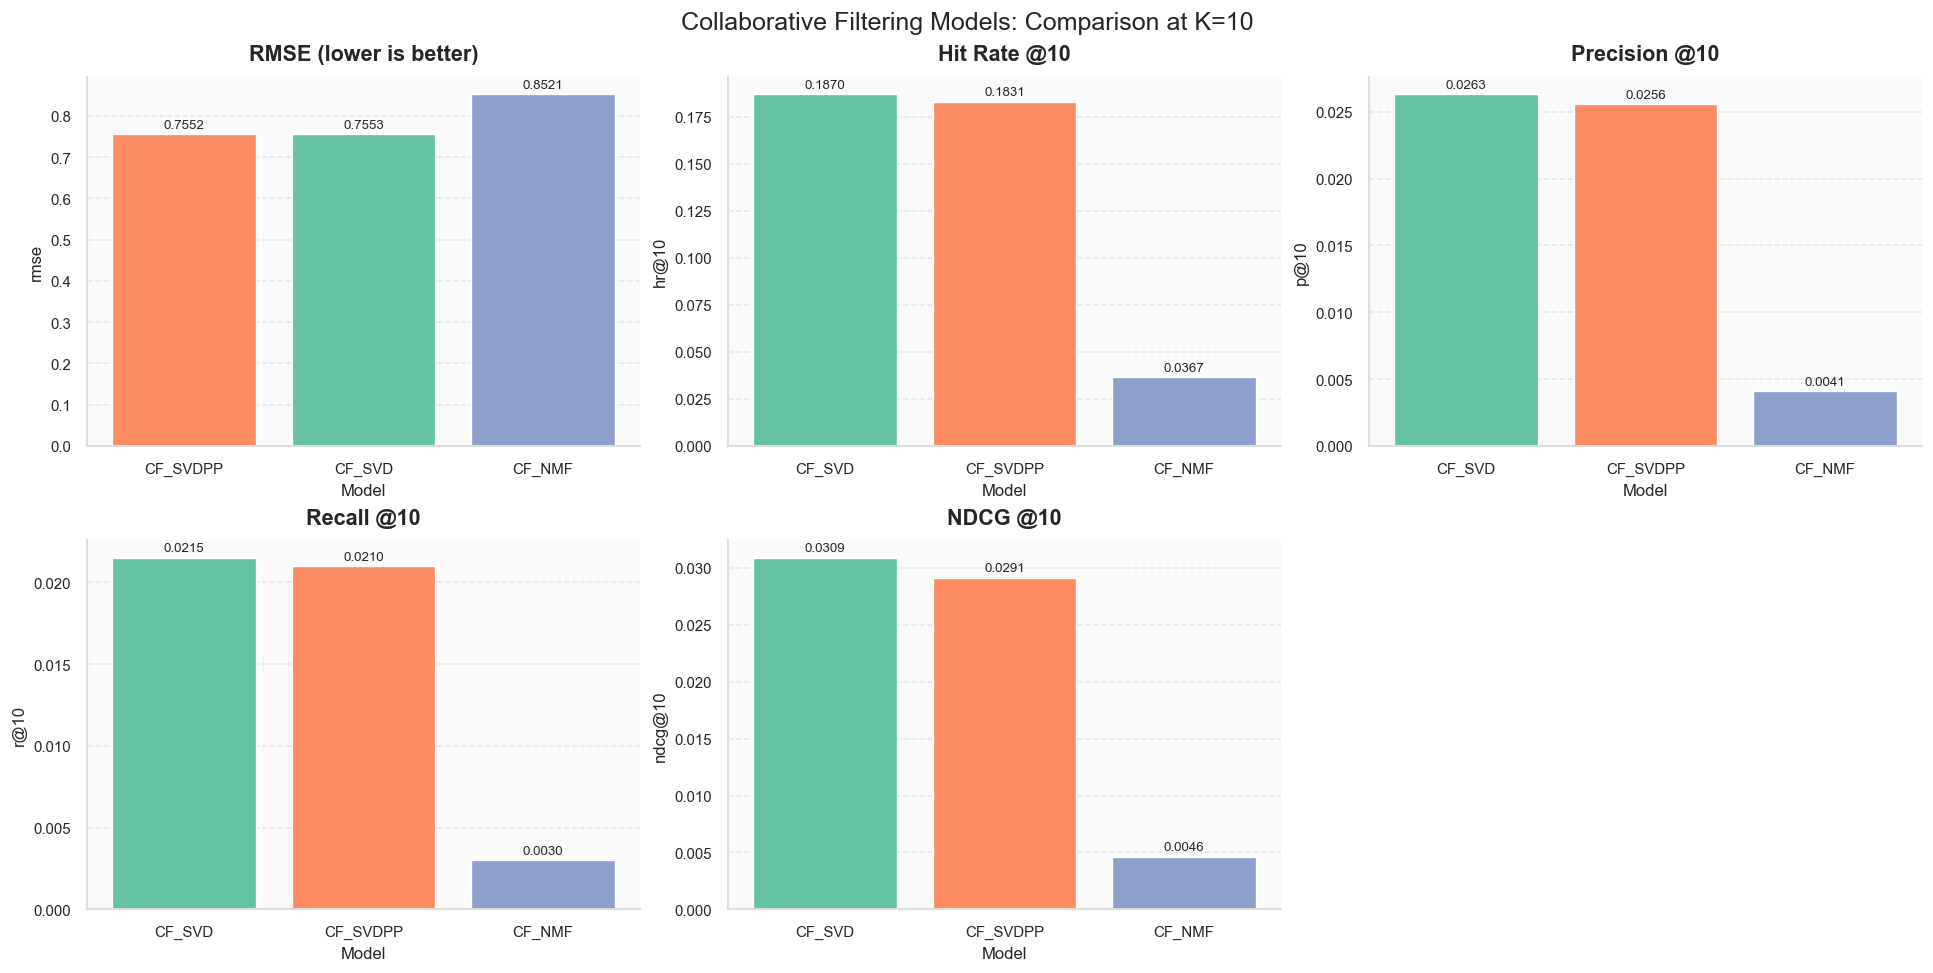

In [52]:
cf_plot_df = cf_df.copy()
model_palette = dict(zip(cf_plot_df["model"], sns.color_palette("Set2", n_colors=len(cf_plot_df))))

fig, axes = plt.subplots(2, 3, figsize=(16, 8), constrained_layout=True)

metrics = ["rmse", "hr@10", "p@10", "r@10", "ndcg@10"]
titles = ["RMSE (lower is better)", "Hit Rate @10", "Precision @10", "Recall @10", "NDCG @10"]

for ax, metric, title in zip(axes.flat, metrics, titles):
    ascending = metric == "rmse"
    tmp = cf_plot_df.sort_values(metric, ascending=ascending)
    bars = ax.bar(
        tmp["model"],
        tmp[metric],
        color=[model_palette[m] for m in tmp["model"]],
        edgecolor="white",
        linewidth=0.8
    )
    ax.set_title(title, pad=10)
    ax.set_xlabel("Model")
    ax.tick_params(axis="x", rotation=0)
    style_axis(ax, metric)
    labels = [f"{v:.4f}" if v == v else "" for v in bars.datavalues]
    ax.bar_label(bars, labels=labels, padding=2, fontsize=8)

# Hide the 6th empty subplot
axes.flat[-1].axis("off")

fig.suptitle("Collaborative Filtering Models: Comparison at K=10", fontsize=15)
plt.show()

### Trends across K = 5, 10, 20

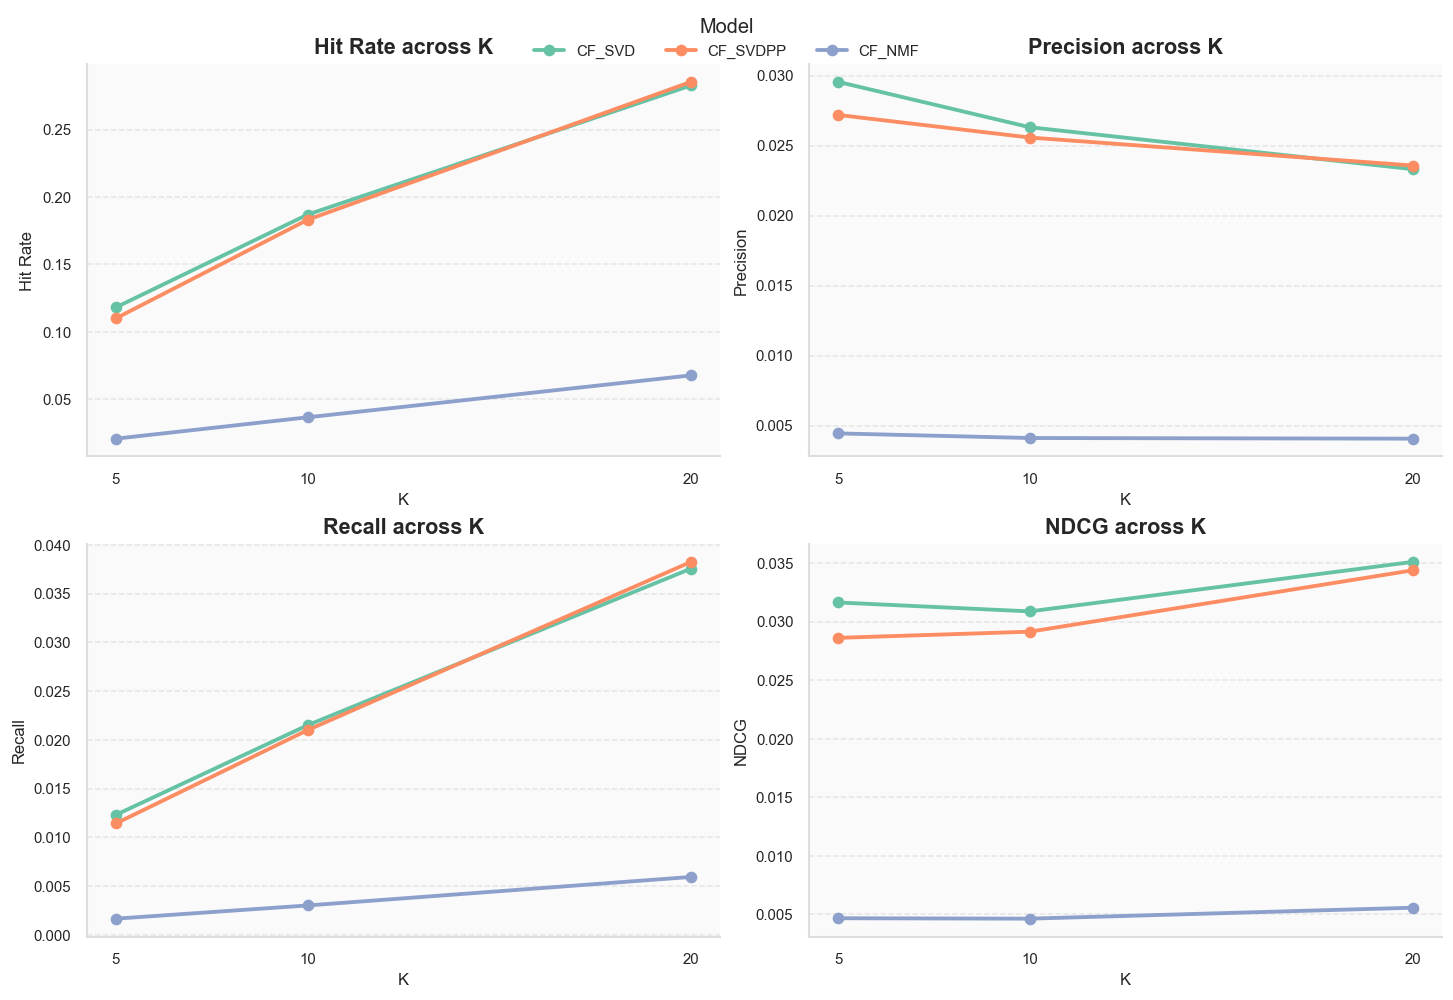

Best by RMSE: CF_SVDPP
Best by NDCG@10: CF_SVD


In [53]:
k_values = [5, 10, 20]
metric_roots = ["hr", "p", "r", "ndcg"]
metric_titles = ["Hit Rate", "Precision", "Recall", "NDCG"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, root, title in zip(axes.flat, metric_roots, metric_titles):
    for _, row in cf_plot_df.iterrows():
        y = [row[f"{root}@{k}"] for k in k_values]
        ax.plot(
            k_values,
            y,
            marker="o",
            linewidth=2.3,
            markersize=6,
            color=model_palette[row["model"]],
            label=row["model"]
        )
    ax.set_title(f"{title} across K")
    ax.set_xlabel("K")
    ax.set_ylabel(title)
    ax.set_xticks(k_values)
    style_axis(ax)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Model", loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.03))
plt.show()

# Identify best models by RMSE and NDCG@10
print("Best by RMSE:", cf_plot_df.loc[cf_plot_df["rmse"].idxmin(), "model"])
print("Best by NDCG@10:", cf_plot_df.loc[cf_plot_df["ndcg@10"].idxmax(), "model"])

## Comparison - Best Content-Based vs Best Collaborative Filtering

In [54]:
# Best models by NDCG@10
best_cb = plot_df.loc[plot_df["ndcg@10"].idxmax()]
best_cf = cf_plot_df.loc[cf_plot_df["ndcg@10"].idxmax()]

print("Best CB:", best_cb["model"])
print("Best CF:", best_cf["model"])

Best CB: cb4_mean_centering
Best CF: CF_SVD


### Direct comparison at K=10

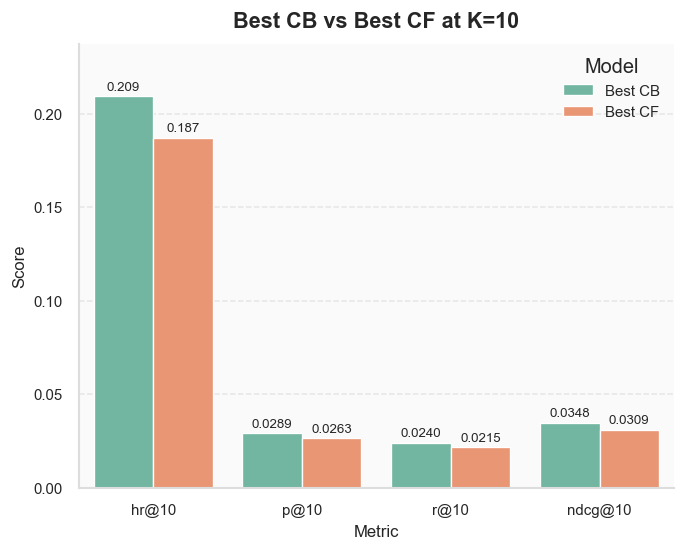

In [55]:
metrics_k10 = ["hr@10", "p@10", "r@10", "ndcg@10"]
compare_k10 = pd.DataFrame({
    "metric": metrics_k10,
    "Best CB": [best_cb[m] for m in metrics_k10],
    "Best CF": [best_cf[m] for m in metrics_k10],
})

compare_long = compare_k10.melt(id_vars="metric", var_name="Model", value_name="Score")
ax = sns.barplot(
    data=compare_long,
    x="metric",
    y="Score",
    hue="Model",
    palette=sns.color_palette("Set2", n_colors=2),
    edgecolor="white",
    linewidth=0.8
)
ax.set_title("Best CB vs Best CF at K=10", pad=10)
ax.set_xlabel("Metric")
style_axis(ax, "Score")
add_bar_labels(ax)
ax.legend(title="Model")
plt.show()

### Trends across K = 5, 10, 20

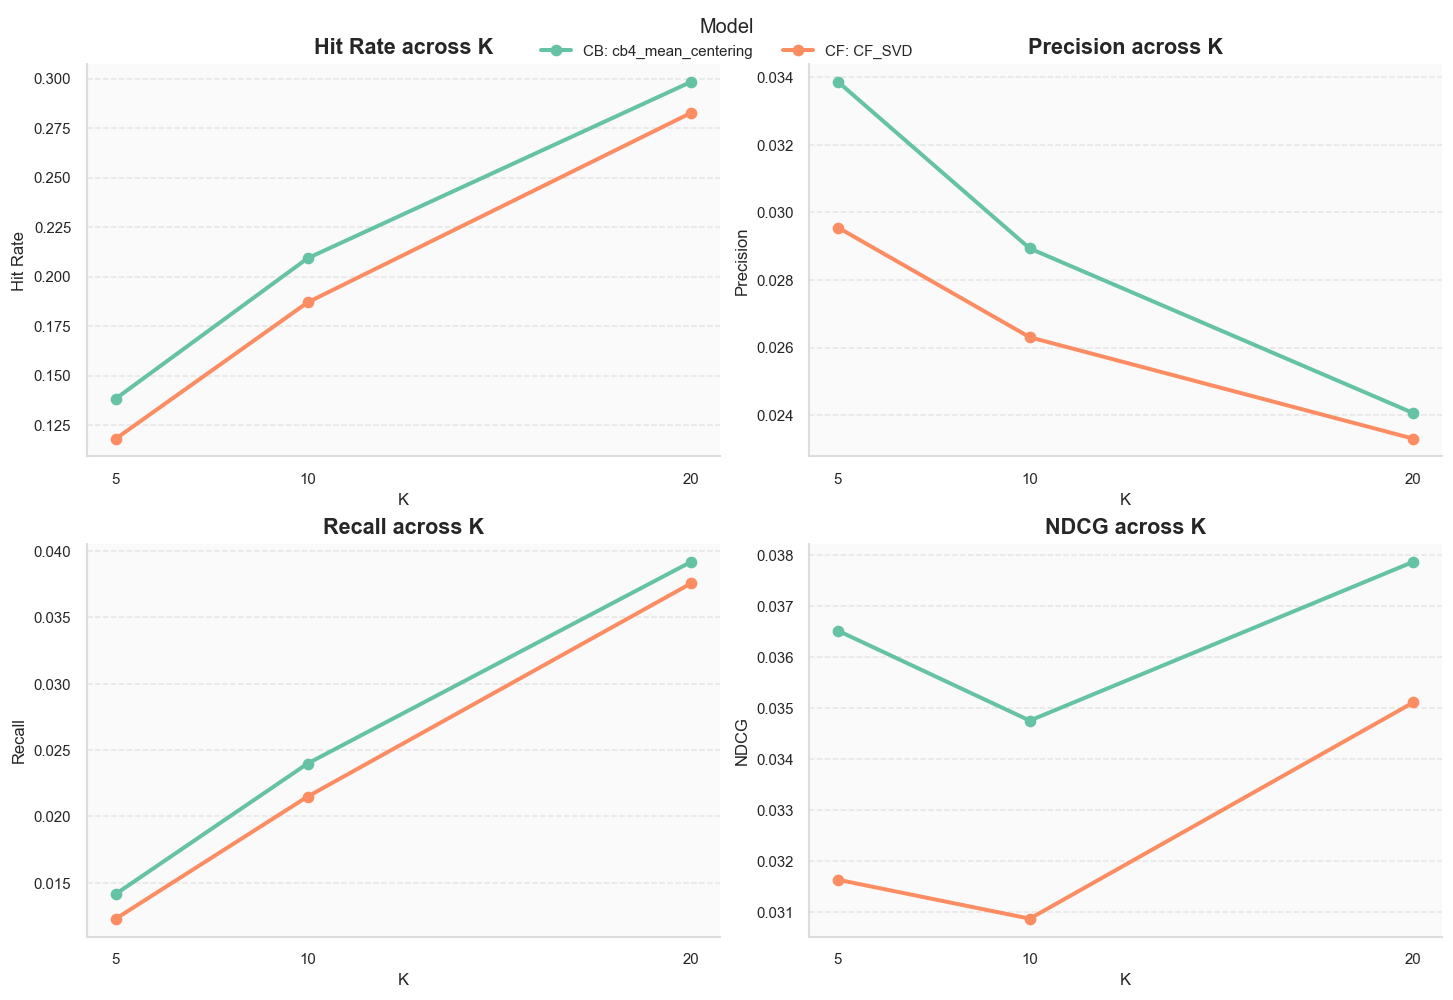

In [56]:
k_values = [5, 10, 20]
metric_roots = ["hr", "p", "r", "ndcg"]
metric_titles = ["Hit Rate", "Precision", "Recall", "NDCG"]
pair_palette = sns.color_palette("Set2", n_colors=2)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for ax, root, title in zip(axes.flat, metric_roots, metric_titles):
    cb_y = [best_cb[f"{root}@{k}"] for k in k_values]
    cf_y = [best_cf[f"{root}@{k}"] for k in k_values]

    ax.plot(
        k_values, cb_y, marker="o", linewidth=2.4, markersize=6,
        color=pair_palette[0], label=f'CB: {best_cb["model"]}'
    )
    ax.plot(
        k_values, cf_y, marker="o", linewidth=2.4, markersize=6,
        color=pair_palette[1], label=f'CF: {best_cf["model"]}'
    )
    ax.set_title(f"{title} across K")
    ax.set_xlabel("K")
    ax.set_ylabel(title)
    ax.set_xticks(k_values)
    style_axis(ax)

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, title="Model", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.03))
plt.show()